In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import warnings 
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('loan_data.csv')

In [3]:
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [4]:
df.shape

(45000, 14)

In [5]:
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  str    
 2   person_education                45000 non-null  str    
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  str    
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  str    
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  45000 non-n

In [7]:
df.duplicated().sum()

np.int64(0)

In [14]:
df['loan_status'].value_counts()

loan_status
0    35000
1    10000
Name: count, dtype: int64

In [15]:
df.nunique().sort_values()

person_gender                         2
previous_loan_defaults_on_file        2
loan_status                           2
person_home_ownership                 4
person_education                      5
loan_intent                           6
cb_person_cred_hist_length           29
person_age                           60
person_emp_exp                       63
loan_percent_income                  64
credit_score                        340
loan_int_rate                      1302
loan_amnt                          4483
person_income                     33989
dtype: int64

In [69]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()
num_cols.remove('loan_status')

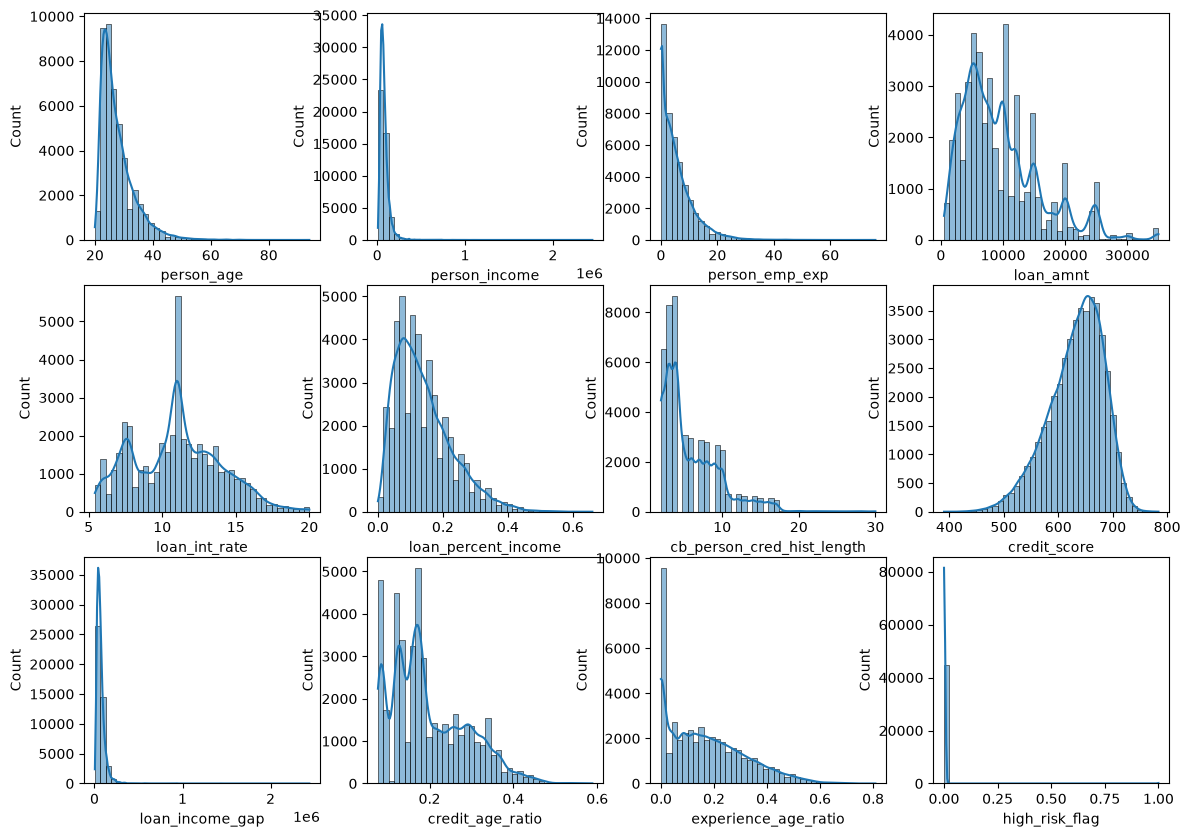

In [70]:
i=1
plt.figure(figsize=(14,10))
for col in num_cols:
    plt.subplot(3,4,i)
    sns.histplot(
        df,
        x=col,kde=True,bins=40
    )
    i+=1

In [71]:
df[num_cols].skew().sort_values(ascending=False)

high_risk_flag                21.248695
loan_income_gap               10.378657
person_income                  9.694992
person_emp_exp                 1.952045
person_age                     1.910603
cb_person_cred_hist_length     1.629395
loan_amnt                      1.179784
loan_percent_income            1.034842
credit_age_ratio               0.745821
experience_age_ratio           0.712476
loan_int_rate                  0.213915
credit_score                  -0.615329
dtype: float64

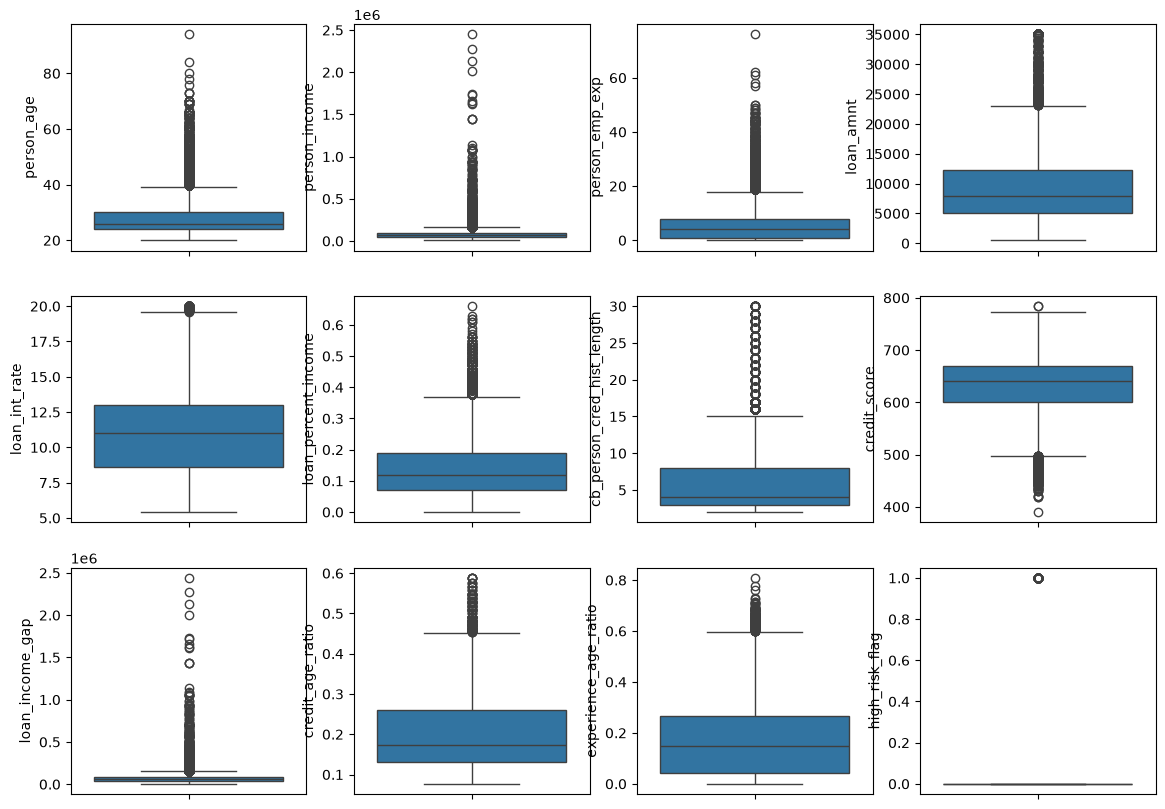

In [73]:
i=1
plt.figure(figsize=(14,10))
for col in num_cols:
    plt.subplot(3,4,i)
    sns.boxplot(data=df,y=col)
    i+=1

In [36]:
df=df[df['person_age']<100]

In [74]:
def outlier_summary(df):
    report = []

    for col in num_cols:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        count = df[(df[col] < lower) | (df[col] > upper)].shape[0]

        report.append([col, count, round(count/len(df)*100,2)])

    return pd.DataFrame(report, columns=[
        "Feature","Outliers","Outlier %"
    ])

outlier_summary(df)

,Feature,Outliers,Outlier %
0,person_age,2181,4.85
1,person_income,2214,4.92
2,person_emp_exp,1717,3.82
3,loan_amnt,2348,5.22
4,loan_int_rate,124,0.28
5,loan_percent_income,744,1.65
6,cb_person_cred_hist_length,1363,3.03
7,credit_score,462,1.03
8,loan_income_gap,2254,5.01
9,credit_age_ratio,237,0.53


<Axes: >

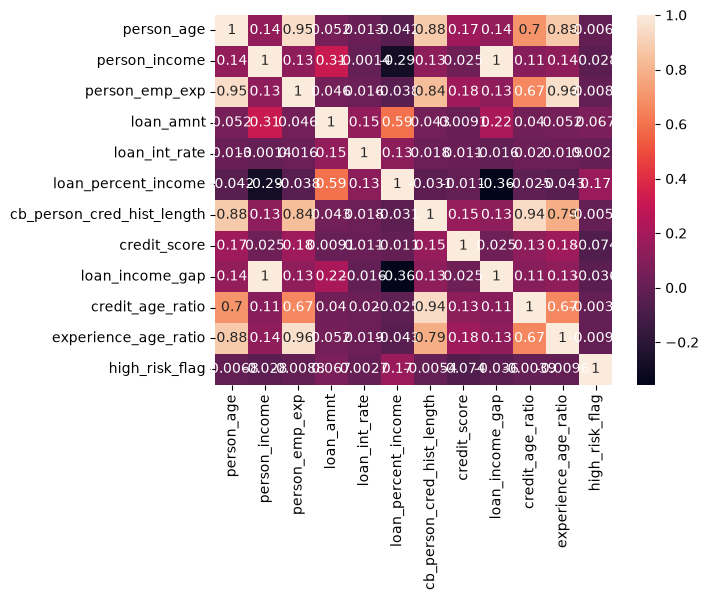

In [75]:
sns.heatmap(df[num_cols].corr(),annot=True)

In [49]:
df[(df['credit_score']<300)|(df['credit_score']>850)]

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status


In [51]:
df[df["loan_percent_income"] > 1]

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status


In [52]:
df["age_group"] = pd.cut(
    df["person_age"],
    bins=[18,25,35,45,55,65,100],
    labels=[
        "18-25",
        "26-35",
        "36-45",
        "46-55",
        "56-65",
        "65+"
    ]
)

In [53]:
age_distribution = (
    df["age_group"]
      .value_counts()
      .sort_index()
)

age_distribution

age_group
18-25    20441
26-35    20073
36-45     3724
46-55      605
56-65      118
65+         32
Name: count, dtype: int64

In [54]:
approval_age = (
    df.groupby("age_group")["loan_status"]
      .mean()
      .mul(100)
      .round(2)
)

approval_age

age_group
18-25    23.39
26-35    21.31
36-45    20.62
46-55    22.48
56-65    26.27
65+      15.62
Name: loan_status, dtype: float64

In [55]:
df["loan_status"].value_counts(normalize=True) * 100

loan_status
0    77.77432
1    22.22568
Name: proportion, dtype: float64

In [56]:
age_summary = pd.DataFrame({
    "Applicants": df["age_group"].value_counts().sort_index()
})

age_summary["Applicant %"] = (
    age_summary["Applicants"] / len(df) * 100
).round(2)

age_summary

,Applicants,Applicant %
age_group,,
18-25,20441,45.43
26-35,20073,44.61
36-45,3724,8.28
46-55,605,1.34
56-65,118,0.26
65+,32,0.07


In [57]:
df["credit_band"] = pd.cut(
    df["credit_score"],
    bins=[300,580,670,740,800,850],
    labels=[
        "Poor",
        "Fair",
        "Good",
        "Very Good",
        "Excellent"
    ]
)

In [59]:
credit_band_approval = (
    df.groupby("credit_band")["loan_status"]
      .mean()
      .mul(100)
      .round(2)
)
credit_band_approval

credit_band
Poor         22.31
Fair         22.45
Good         21.62
Very Good    21.69
Name: loan_status, dtype: float64

In [62]:
intent_count = df["loan_intent"].value_counts()
intent_count

loan_intent
EDUCATION            9151
MEDICAL              8548
VENTURE              7815
PERSONAL             7551
DEBTCONSOLIDATION    7145
HOMEIMPROVEMENT      4783
Name: count, dtype: int64

In [63]:
intent_approval = (
    df.groupby("loan_intent")["loan_status"]
      .mean()
      .mul(100)
      .round(2)
)
intent_approval

loan_intent
DEBTCONSOLIDATION    30.27
EDUCATION            16.96
HOMEIMPROVEMENT      26.30
MEDICAL              27.82
PERSONAL             20.14
VENTURE              14.43
Name: loan_status, dtype: float64

In [64]:
education_approval = (
    df.groupby("person_education")["loan_status"]
      .mean()
      .mul(100)
      .round(2)
) 
education_approval

person_education
Associate      22.04
Bachelor       22.53
Doctorate      22.87
High School    22.31
Master         21.76
Name: loan_status, dtype: float64

In [65]:
df["loan_income_gap"] = (
    df["person_income"] - df["loan_amnt"]
)

In [66]:
df["credit_age_ratio"] = (
    df["cb_person_cred_hist_length"] /
    df["person_age"]
)
df["experience_age_ratio"] = (
    df["person_emp_exp"] /
    df["person_age"]
) 
df["high_risk_flag"] = np.where(
    (df["credit_score"]<600) &
    (df["loan_percent_income"]>0.4),
    1,
    0
)

In [68]:
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status,loan_income_gap,credit_age_ratio,experience_age_ratio,high_risk_flag
count,44993.000000,4.499300e+04,44993.000000,44993.000000,44993.000000,44993.000000,44993.000000,44993.000000,44993.000000,4.499300e+04,44993.000000,44993.000000,44993.000000
mean,27.748428,7.990845e+04,5.394528,9583.176761,11.006448,0.139736,5.866557,632.585713,0.222257,7.032527e+04,0.197981,0.167274,0.002200
std,5.909737,6.332213e+04,5.927159,6314.802655,2.978985,0.087207,3.877167,50.402411,0.415767,6.164171e+04,0.089928,0.144927,0.046857
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000,4.787000e+03,0.076923,0.000000,0.000000
25%,24.000000,4.719500e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000,3.907300e+04,0.130435,0.041667,0.000000
50%,26.000000,6.704600e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000,5.789200e+04,0.173913,0.148148,0.000000
75%,30.000000,9.577800e+04,8.000000,12237.000000,12.990000,0.190000,8.000000,670.000000,0.000000,8.446600e+04,0.259259,0.264706,0.000000
max,94.000000,2.448661e+06,76.000000,35000.000000,20.000000,0.660000,30.000000,784.000000,1.000000,2.440211e+06,0.588235,0.808511,1.000000


In [76]:
X=df.drop('loan_status',axis=1)
y=df['loan_status']

In [113]:
numerical_features = X_encoded.select_dtypes(include="number").columns.tolist()

categorical_features = X_encoded.select_dtypes(exclude="number").columns.tolist()

In [78]:
df["person_gender"] = df["person_gender"].map({
    "male":0,
    "female":1
})

df["previous_loan_defaults_on_file"] = (
    df["previous_loan_defaults_on_file"]
      .map({
          "No":0,
          "Yes":1
      })
)

In [79]:
X_encoded = pd.get_dummies(
    X,
    columns=[
        "person_home_ownership",
        "person_education",
        "loan_intent"
    ],
    drop_first=True,
    dtype=int
)

In [80]:
df["person_income_log"] = np.log1p(
    df["person_income"]
)

df["loan_amnt_log"] = np.log1p(
    df["loan_amnt"]
)

In [81]:
print(df["person_income"].skew())

print(df["person_income_log"].skew())

9.694992309322467
0.19165436984521378


In [82]:
lower = df["person_income"].quantile(0.01)

upper = df["person_income"].quantile(0.99)

df["person_income_capped"] = (
    df["person_income"]
      .clip(lower, upper)
)

In [83]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    X_encoded[numerical_features]
)

In [117]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [86]:
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score,classification_report

In [87]:
model1=GaussianNB()
model2=LogisticRegression()
model3=SVC()
model4=DecisionTreeClassifier()
model5=KNeighborsClassifier()

In [118]:
model1.fit(X_train,y_train)
model2.fit(X_train,y_train)
model3.fit(X_train,y_train)
model4.fit(X_train,y_train)
model5.fit(X_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [89]:
X_encoded.head()

,person_age,person_gender,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,...,person_home_ownership_RENT,person_education_Bachelor,person_education_Doctorate,person_education_High School,person_education_Master,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,22.0,female,71948.0,0,35000.0,16.02,0.49,3.0,561,No,...,1,0,0,0,1,0,0,0,1,0
1,21.0,female,12282.0,0,1000.0,11.14,0.08,2.0,504,Yes,...,0,0,0,1,0,1,0,0,0,0
2,25.0,female,12438.0,3,5500.0,12.87,0.44,3.0,635,No,...,0,0,0,1,0,0,0,1,0,0
3,23.0,female,79753.0,0,35000.0,15.23,0.44,2.0,675,No,...,1,1,0,0,0,0,0,1,0,0
4,24.0,male,66135.0,1,35000.0,14.27,0.53,4.0,586,No,...,1,0,0,0,1,0,0,1,0,0


In [90]:
X_encoded.rename(columns=({'person_gender':'is_male'}))
X_encoded['person_gender']=X_encoded['person_gender'].map({'female':0,'male':1})
X_encoded['previous_loan_defaults_on_file']=X_encoded['previous_loan_defaults_on_file'].map({'No':0,'Yes':1})

In [100]:
X_encoded.info()

<class 'pandas.DataFrame'>
Index: 44993 entries, 0 to 44999
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      44993 non-null  float64
 1   person_gender                   44993 non-null  int64  
 2   person_income                   44993 non-null  float64
 3   person_emp_exp                  44993 non-null  int64  
 4   loan_amnt                       44993 non-null  float64
 5   loan_int_rate                   44993 non-null  float64
 6   loan_percent_income             44993 non-null  float64
 7   cb_person_cred_hist_length      44993 non-null  float64
 8   credit_score                    44993 non-null  int64  
 9   previous_loan_defaults_on_file  44993 non-null  int64  
 10  loan_income_gap                 44993 non-null  float64
 11  credit_age_ratio                44993 non-null  float64
 12  experience_age_ratio            44993 non-null  

In [97]:
X_encoded.drop(columns=(['age_group','credit_band']),inplace=True)

In [119]:
y_pred1=model1.predict(X_test)
y_pred2=model2.predict(X_test)
y_pred3=model3.predict(X_test)
y_pred4=model4.predict(X_test)
y_pred5=model5.predict(X_test)

In [104]:
print(accuracy_score(y_test,y_pred1))
print(accuracy_score(y_test,y_pred2))
print(accuracy_score(y_test,y_pred3))
print(accuracy_score(y_test,y_pred4))
print(accuracy_score(y_test,y_pred5))

0.8132014668296478
0.8265362818090899
0.8095343927103011
0.901766862984776
0.8326480720080008


In [120]:
print(classification_report(y_test,y_pred1))
print(classification_report(y_test,y_pred2))
print(classification_report(y_test,y_pred3))
print(classification_report(y_test,y_pred4))
print(classification_report(y_test,y_pred5))

              precision    recall  f1-score   support

           0       0.84      0.95      0.89      6999
           1       0.68      0.38      0.49      2000

    accuracy                           0.82      8999
   macro avg       0.76      0.66      0.69      8999
weighted avg       0.81      0.82      0.80      8999

              precision    recall  f1-score   support

           0       0.85      0.94      0.89      6999
           1       0.67      0.40      0.50      2000

    accuracy                           0.82      8999
   macro avg       0.76      0.67      0.70      8999
weighted avg       0.81      0.82      0.81      8999

              precision    recall  f1-score   support

           0       0.85      0.95      0.90      6999
           1       0.73      0.43      0.54      2000

    accuracy                           0.84      8999
   macro avg       0.79      0.69      0.72      8999
weighted avg       0.83      0.84      0.82      8999

              preci

In [106]:
model6=DecisionTreeClassifier(class_weight='balanced')
model6.fit(X_train,y_train)

,"class_weight class_weight: dict, list of dict or ""balanced"", default=NoneWeights associated with classes in the form ``{class_label: weight}``.If None, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But

In [107]:
pred_6=model6.predict(X_test)

In [108]:
print(classification_report(y_test,y_pred1))

              precision    recall  f1-score   support

           0       0.86      0.91      0.88      6999
           1       0.60      0.46      0.52      2000

    accuracy                           0.81      8999
   macro avg       0.73      0.69      0.70      8999
weighted avg       0.80      0.81      0.80      8999



In [109]:
X_encoded.columns

Index(['person_age', 'person_gender', 'person_income', 'person_emp_exp',
       'loan_amnt', 'loan_int_rate', 'loan_percent_income',
       'cb_person_cred_hist_length', 'credit_score',
       'previous_loan_defaults_on_file', 'loan_income_gap', 'credit_age_ratio',
       'experience_age_ratio', 'high_risk_flag', 'person_home_ownership_OTHER',
       'person_home_ownership_OWN', 'person_home_ownership_RENT',
       'person_education_Bachelor', 'person_education_Doctorate',
       'person_education_High School', 'person_education_Master',
       'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT',
       'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE'],
      dtype='str')

In [112]:
import joblib 
joblib.dump(model4,'DT_loan.pkl')
joblib.dump(X_encoded.columns.to_list(),'columns.pkl')

['columns.pkl']

In [116]:
X_encoded.head()

,person_age,person_gender,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,...,person_home_ownership_RENT,person_education_Bachelor,person_education_Doctorate,person_education_High School,person_education_Master,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,22.0,0,71948.0,0,35000.0,16.02,0.49,3.0,561,0,...,1,0,0,0,1,0,0,0,1,0
1,21.0,0,12282.0,0,1000.0,11.14,0.08,2.0,504,1,...,0,0,0,1,0,1,0,0,0,0
2,25.0,0,12438.0,3,5500.0,12.87,0.44,3.0,635,0,...,0,0,0,1,0,0,0,1,0,0
3,23.0,0,79753.0,0,35000.0,15.23,0.44,2.0,675,0,...,1,1,0,0,0,0,0,1,0,0
4,24.0,1,66135.0,1,35000.0,14.27,0.53,4.0,586,0,...,1,0,0,0,1,0,0,1,0,0
